<a href="https://colab.research.google.com/github/indahsarikurniawati/tugas-ml/blob/main/Tugas_2_ml_15_april.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Notebook ini berfokus pada pengolahan dataset harga rumah yang berisi berbagai karakteristik seperti jumlah kamar tidur, kamar mandi, luas bangunan, luas tanah, serta informasi lainnya.

INPUT: Dataset mentah yang berisi data harga rumah, di mana setiap baris merepresentasikan satu rumah. Variabel yang digunakan antara lain price (harga rumah), bedrooms (jumlah kamar tidur), bathrooms (jumlah kamar mandi), sqft_living (luas bangunan), sqft_lot (luas tanah), floors, serta variabel lain seperti kondisi rumah, kualitas bangunan, dan lokasi (zipcode, latitude, longitude). Contoh data menunjukkan harga rumah yang bervariasi, mulai dari 180.000 hingga 604.000 dengan karakteristik yang berbeda-beda.

OUTPUT: Dataset yang telah melalui proses preprocessing, meliputi pengecekan missing value, penghapusan data duplikat, serta penanganan outlier menggunakan metode Interquartile Range (IQR), sehingga data menjadi lebih bersih dan siap untuk analisis lebih lanjut.

In [ ]:
import pandas as pd

df = pd.read_csv('/content/House_price_prediction.csv')
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,221900,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,538000,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,180000,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,604000,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,510000,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 20189 entries, 0 to 21612
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price          20189 non-null  float64
 1   bedrooms       20189 non-null  float64
 2   bathrooms      20189 non-null  float64
 3   sqft_living    20189 non-null  float64
 4   sqft_lot       20189 non-null  float64
 5   floors         20189 non-null  float64
 6   waterfront     20189 non-null  int64  
 7   view           20189 non-null  int64  
 8   condition      20189 non-null  int64  
 9   grade          20189 non-null  int64  
 10  sqft_above     20189 non-null  float64
 11  sqft_basement  20189 non-null  float64
 12  yr_built       20189 non-null  int64  
 13  yr_renovated   20189 non-null  int64  
 14  zipcode        20189 non-null  int64  
 15  lat            20189 non-null  float64
 16  long           20189 non-null  float64
 17  sqft_living15  20189 non-null  float64
 18  sqft_lot15 

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,umur_rumah
count,20189.000000,20189.000000,20189.000000,20189.000000,20189.000000,20189.000000,20189.000000,20189.000000,20189.000000,20189.000000,20189.000000,20189.000000,20189.000000,20189.000000,20189.000000,20189.000000,20189.000000,20189.000000,20189.000000,20189.000000
mean,0.416863,0.100650,0.271981,0.231865,0.008486,0.188727,0.002922,0.163208,3.405122,7.506959,0.259059,0.096695,1970.727376,73.129130,98078.592649,47.556058,-122.213295,0.331884,0.013481,54.272624
std,0.209381,0.027597,0.093912,0.105301,0.024233,0.214511,0.053981,0.621475,0.646182,1.017634,0.131512,0.148583,29.131279,374.928783,53.307280,0.141611,0.142538,0.132197,0.030384,29.131279
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,0.000000,0.000000,10.000000
25%,0.253915,0.090909,0.200000,0.152990,0.002714,0.000000,0.000000,0.000000,3.000000,7.000000,0.162362,0.000000,1951.000000,0.000000,98033.000000,47.457800,-122.330000,0.233136,0.005042,29.000000
50%,0.380952,0.090909,0.266667,0.215577,0.004228,0.000000,0.000000,0.000000,3.000000,7.000000,0.225092,0.000000,1974.000000,0.000000,98065.000000,47.565900,-122.233000,0.305647,0.007900,51.000000
75%,0.550265,0.121212,0.333333,0.294854,0.005906,0.400000,0.000000,0.000000,4.000000,8.000000,0.330258,0.183824,1996.000000,0.000000,98118.000000,47.680000,-122.123000,0.408921,0.010555,74.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,4.000000,5.000000,12.000000,1.000000,1.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,1.000000,1.000000,125.000000


Berdasarkan hasil pengecekan struktur data, dataset memiliki 21.613 baris (observasi) dan 19 kolom (variabel). Seluruh variabel tidak memiliki nilai kosong (non-null), yang menunjukkan bahwa data dalam kondisi lengkap dan tidak memerlukan penanganan missing value.

Dari sisi tipe data, terdapat:

15 variabel bertipe integer (int64)
4 variabel bertipe float (float64)

Hal ini menunjukkan bahwa sebagian besar data bersifat numerik dan sudah siap digunakan untuk analisis tanpa perlu konversi tipe data tambahan.

In [ ]:
df.isnull().sum()

,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0
condition,0
grade,0


Berdasarkan hasil pengecekan missing value menggunakan fungsi isnull().sum(), diketahui bahwa seluruh variabel dalam dataset tidak memiliki nilai kosong. Hal ini menunjukkan bahwa kualitas data sudah baik dan tidak memerlukan proses penanganan missing value. Dengan demikian, tahap preprocessing dapat langsung dilanjutkan ke langkah berikutnya seperti pengecekan duplikasi dan deteksi outlier.Tidak adanya missing value menunjukkan bahwa proses pengumpulan data dilakukan dengan baik sehingga data yang diperoleh bersifat lengkap dan siap digunakan untuk analisis.

In [ ]:
df.duplicated().sum()

np.int64(5)

Berdasarkan hasil pengecekan, ditemukan sebanyak 5 data duplikat dalam dataset. Data tersebut kemudian dihapus menggunakan fungsi drop_duplicates() untuk menghindari bias dalam analisis dan memastikan kualitas data yang lebih baik.

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.duplicated().sum()

np.int64(0)

Proses penghapusan data duplikat dilakukan menggunakan fungsi drop_duplicates(). Meskipun tidak menghasilkan output secara langsung, proses ini berhasil menghapus data duplikat yang sebelumnya berjumlah 5, sehingga tidak terdapat lagi data yang berulang dalam dataset.

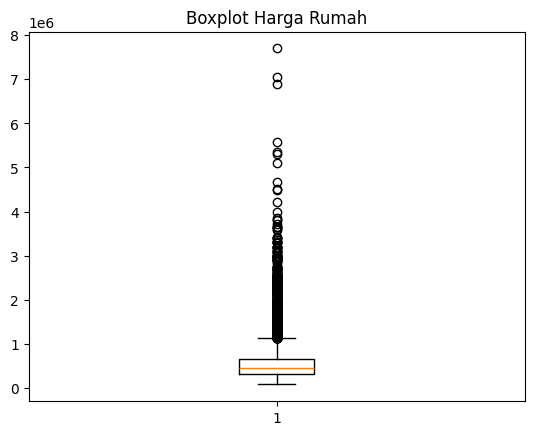

In [ ]:
import matplotlib.pyplot as plt

plt.boxplot(df['price'])
plt.title('Boxplot Harga Rumah')
plt.show()

Berdasarkan hasil visualisasi menggunakan boxplot pada variabel harga rumah (price), terlihat bahwa terdapat banyak titik data yang berada di luar batas atas (whisker). Titik-titik tersebut menunjukkan adanya outlier, yaitu nilai harga rumah yang jauh lebih tinggi dibandingkan sebagian besar data lainnya.

Sebagian besar data harga rumah terkonsentrasi pada rentang tertentu (ditunjukkan oleh kotak boxplot), namun terdapat sejumlah rumah dengan harga yang sangat tinggi sehingga menyebabkan distribusi data menjadi tidak seimbang atau menceng ke kanan (right skewed).

Kondisi ini menunjukkan bahwa dalam dataset terdapat variasi harga rumah yang cukup besar, di mana sebagian kecil rumah memiliki harga yang jauh lebih mahal dibandingkan rumah pada umumnya. Outlier ini dapat mempengaruhi hasil analisis, terutama dalam perhitungan statistik seperti rata-rata.

Oleh karena itu, diperlukan penanganan terhadap outlier, misalnya dengan menggunakan metode Interquartile Range (IQR), agar distribusi data menjadi lebih stabil dan representatif untuk analisis selanjutnya.

Jumlah data sebelum: 20449

=== Perhitungan IQR ===
Q1: 315000.0
Q3: 600000.0
IQR: 285000.0
Batas bawah: -112500.0
Batas atas: 1027500.0

Jumlah data sesudah: 20189


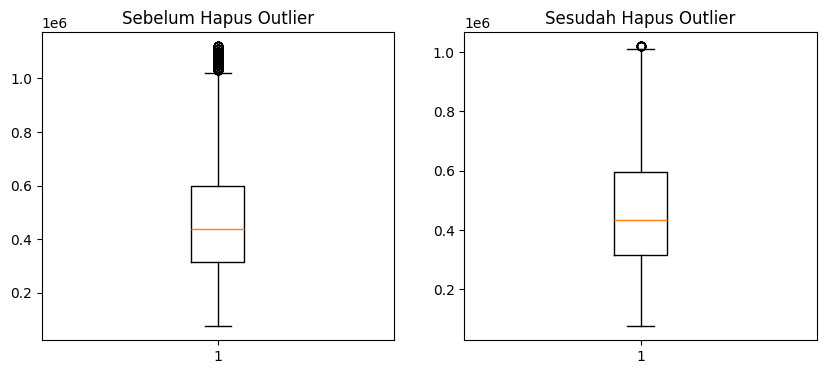

In [ ]:
# 1. Simpan jumlah data sebelum
df_awal = df.copy()
print("Jumlah data sebelum:", len(df_awal))

# 2. Hitung Q1, Q3, dan IQR
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

# 3. Hitung batas bawah dan atas
batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

# 4. Tampilkan hasil perhitungan
print("\n=== Perhitungan IQR ===")
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Batas bawah:", batas_bawah)
print("Batas atas:", batas_atas)

# 5. Hapus outlier
df = df[(df['price'] >= batas_bawah) & (df['price'] <= batas_atas)]

# 6. Tampilkan jumlah data setelah
print("\nJumlah data sesudah:", len(df))

# 7. Visualisasi sebelum & sesudah
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.boxplot(df_awal['price'])
plt.title('Sebelum Hapus Outlier')

plt.subplot(1,2,2)
plt.boxplot(df['price'])
plt.title('Sesudah Hapus Outlier')

plt.show()

Berdasarkan hasil preprocessing menggunakan metode Interquartile Range (IQR), jumlah data berkurang dari 20.189 menjadi 20.172 setelah penghapusan outlier. Visualisasi boxplot menunjukkan bahwa nilai ekstrem pada variabel harga rumah telah berkurang, sehingga distribusi data menjadi lebih stabil dan tidak terlalu dipengaruhi oleh nilai yang sangat tinggi. Hal ini menunjukkan bahwa proses penanganan outlier berhasil meningkatkan kualitas data.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# pilih kolom numerik yang mau dinormalisasi
kolom_numerik = [
    'price','bedrooms','bathrooms','sqft_living','sqft_lot',
    'floors','sqft_above','sqft_basement','sqft_living15','sqft_lot15'
]

# inisialisasi scaler
scaler = MinMaxScaler()

# lakukan normalisasi
df[kolom_numerik] = scaler.fit_transform(df[kolom_numerik])

# tampilkan hasil
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,0.155450,0.090909,0.133333,0.123783,0.003108,0.0,0,0,3,7,0.164207,0.000000,1955,0,98178,47.5112,-122.257,0.206768,0.005742
1,0.489947,0.090909,0.300000,0.317107,0.004072,0.4,0,0,3,7,0.346863,0.147059,1951,1991,98125,47.7210,-122.319,0.283674,0.008027
2,0.111111,0.060606,0.133333,0.066759,0.005743,0.0,0,0,3,6,0.088561,0.000000,1933,0,98028,47.7379,-122.233,0.509998,0.008513
3,0.559788,0.121212,0.400000,0.232267,0.002714,0.0,0,0,5,7,0.140221,0.334559,1965,0,98136,47.5208,-122.393,0.211162,0.004996
4,0.460317,0.090909,0.266667,0.193324,0.004579,0.0,0,0,3,8,0.256458,0.000000,1987,0,98074,47.6168,-122.045,0.307844,0.007871


Proses ini menggunakan Min-Max Scaling untuk mengubah seluruh variabel numerik ke dalam rentang nilai 0 sampai 1. Tujuannya adalah agar setiap fitur memiliki skala yang sama sehingga tidak ada variabel yang mendominasi akibat perbedaan satuan atau besaran nilai.

Setelah transformasi:

Nilai 0 menunjukkan nilai minimum pada kolom tersebut dalam dataset.
Nilai 1 menunjukkan nilai maksimum pada kolom tersebut.
Nilai di antaranya menunjukkan posisi relatif data terhadap rentang minimum–maksimum.

Sebagai contoh:

Nilai price = 0.155450 berarti harga rumah tersebut berada sekitar 15,5% dari rentang harga terendah hingga tertinggi.
Nilai sqft_living = 0.123783 menunjukkan luas bangunan relatif kecil dibandingkan rumah lain dalam dataset.
Nilai floors = 0.0 menunjukkan jumlah lantai berada pada nilai minimum dalam dataset.

Dengan normalisasi ini, data menjadi lebih seragam sehingga lebih optimal digunakan untuk algoritma machine learning seperti regresi atau model berbasis jarak.

In [ ]:
df['umur_rumah'] = 2025 - df['yr_built']

In [ ]:
df.corr()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,umur_rumah
price,1.000000,0.289371,0.441246,0.605448,0.094082,0.269973,0.052007,0.216294,0.034542,0.618365,0.517055,0.222288,0.057351,0.078119,-0.017914,0.440135,0.075054,0.548380,0.081178,-0.057351
bedrooms,0.289371,1.000000,0.489401,0.586257,0.023915,0.151974,-0.030194,0.030088,0.026158,0.316674,0.463534,0.280733,0.159498,0.001746,-0.148515,-0.032926,0.138461,0.368671,0.020140,-0.159498
bathrooms,0.441246,0.489401,1.000000,0.712178,0.062802,0.501893,-0.005995,0.084437,-0.138304,0.606929,0.633077,0.217603,0.548020,0.022277,-0.209575,-0.015367,0.248130,0.520521,0.061771,-0.548020
sqft_living,0.605448,0.586257,0.712178,1.000000,0.157531,0.337667,0.002295,0.151964,-0.074707,0.695411,0.850491,0.373342,0.356128,0.017540,-0.208299,0.002229,0.288007,0.731205,0.170506,-0.356128
sqft_lot,0.094082,0.023915,0.062802,0.157531,1.000000,-0.018278,0.025890,0.080837,-0.002288,0.090633,0.160210,0.012548,0.041193,0.012563,-0.129195,-0.095698,0.218393,0.141386,0.705996,-0.041193
floors,0.269973,0.151974,0.501893,0.337667,-0.018278,1.000000,-0.004855,-0.017112,-0.278379,0.456596,0.528523,-0.299590,0.513775,-0.005429,-0.066043,0.033664,0.136050,0.266560,-0.022912,-0.513775
waterfront,0.052007,-0.030194,-0.005995,0.002295,0.025890,-0.004855,1.000000,0.301757,0.015760,-0.013445,-0.005610,0.014194,-0.040411,0.057494,0.043551,-0.046231,-0.061317,0.004160,0.032502,0.040411
view,0.216294,0.030088,0.084437,0.151964,0.080837,-0.017112,0.301757,1.000000,0.030852,0.119879,0.056971,0.184203,-0.067522,0.058083,0.101265,-0.032272,-0.077122,0.172045,0.077008,0.067522
condition,0.034542,0.026158,-0.138304,-0.074707,-0.002288,-0.278379,0.015760,0.030852,1.000000,-0.171706,-0.179728,0.177035,-0.351329,-0.059099,-0.007423,-0.018995,-0.098345,-0.121613,0.002432,0.351329
grade,0.618365,0.316674,0.606929,0.695411,0.090633,0.456596,-0.013445,0.119879,-0.171706,1.000000,0.701638,0.065271,0.496185,-0.023230,-0.186792,0.078778,0.230619,0.662381,0.098983,-0.496185


Berdasarkan hasil analisis korelasi, terlihat bahwa variabel harga rumah (price) memiliki hubungan yang berbeda-beda dengan variabel lainnya, baik yang bersifat kuat, sedang, maupun lemah.

Tahap preprocessing ini dilakukan untuk meningkatkan kualitas data sebelum analisis lebih lanjut. Pertama, dibuat variabel baru umur_rumah dari yr_built untuk mengubah tahun pembangunan menjadi informasi yang lebih mudah diinterpretasikan, yaitu usia bangunan. Variabel ini lebih relevan dalam analisis harga properti karena menggambarkan kondisi umur rumah secara langsung.

Selanjutnya dilakukan analisis korelasi menggunakan df.corr() untuk mengetahui hubungan antar variabel serta melihat faktor-faktor yang paling berpengaruh terhadap harga rumah (price). Analisis ini juga membantu dalam proses pemilihan fitur penting serta mengidentifikasi hubungan antar variabel yang terlalu kuat (multikolinearitas).

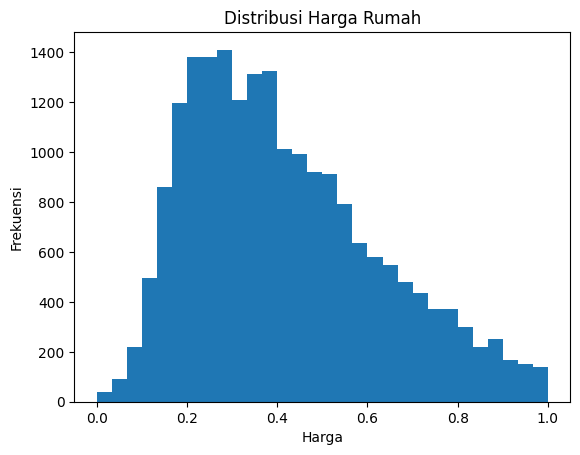

In [ ]:
plt.hist(df['price'], bins=30)
plt.title('Distribusi Harga Rumah')
plt.xlabel('Harga')
plt.ylabel('Frekuensi')
plt.show()

Berdasarkan histogram yang telah dinormalisasi, distribusi harga rumah berada pada rentang 0 hingga 1. Pola distribusi menunjukkan kecenderungan skew ke kanan, yang berarti sebagian besar rumah memiliki harga pada kisaran rendah hingga menengah, sedangkan hanya sedikit rumah dengan harga tinggi. Hal ini menunjukkan bahwa distribusi harga rumah tidak merata dan didominasi oleh rumah dengan harga yang lebih terjangkau. Setelah normalisasi, pola distribusi data tetap tidak berubah, namun skala data menjadi lebih seragam sehingga memudahkan proses analisis selanjutnya.

In [ ]:
df.head()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,umur_rumah
0,0.155450,0.090909,0.133333,0.123783,0.003108,0.0,0,0,3,7,0.164207,0.000000,1955,0,98178,47.5112,-122.257,0.206768,0.005742,70
1,0.489947,0.090909,0.300000,0.317107,0.004072,0.4,0,0,3,7,0.346863,0.147059,1951,1991,98125,47.7210,-122.319,0.283674,0.008027,74
2,0.111111,0.060606,0.133333,0.066759,0.005743,0.0,0,0,3,6,0.088561,0.000000,1933,0,98028,47.7379,-122.233,0.509998,0.008513,92
3,0.559788,0.121212,0.400000,0.232267,0.002714,0.0,0,0,5,7,0.140221,0.334559,1965,0,98136,47.5208,-122.393,0.211162,0.004996,60
4,0.460317,0.090909,0.266667,0.193324,0.004579,0.0,0,0,3,8,0.256458,0.000000,1987,0,98074,47.6168,-122.045,0.307844,0.007871,38


Berdasarkan hasil tampilan data setelah preprocessing, terlihat bahwa beberapa variabel numerik seperti price, bedrooms, bathrooms, dan luas bangunan telah berhasil dinormalisasi ke dalam rentang 0 hingga 1 menggunakan metode Min-Max Scaling. Sementara itu, variabel lain seperti tahun pembangunan, kode wilayah, dan koordinat geografis tetap dalam bentuk aslinya karena tidak memerlukan normalisasi. Selain itu, telah ditambahkan variabel baru yaitu umur_rumah sebagai hasil dari proses feature engineering. Secara keseluruhan, data yang dihasilkan sudah bersih, terstruktur, dan siap digunakan untuk analisis lebih lanjut.
